   id                           nome    categoria   preco  quantidade  \
0   1         Notebook Dell Inspiron  Eletrônicos  3899.9          12   
1   2  Smartphone Samsung Galaxy A32  Eletrônicos  1499.0          30   
2   3            Cadeira Gamer Mymax   Escritório   799.9           7   
3   4                Caneta Bic Azul    Papelaria     1.5         500   
4   5              Livro: Clean Code       Livros    99.9          15   

   estoque_minimo  
0               5  
1              10  
2               3  
3             200  
4               5  
Total de valor em estoque: R$ 130914.90


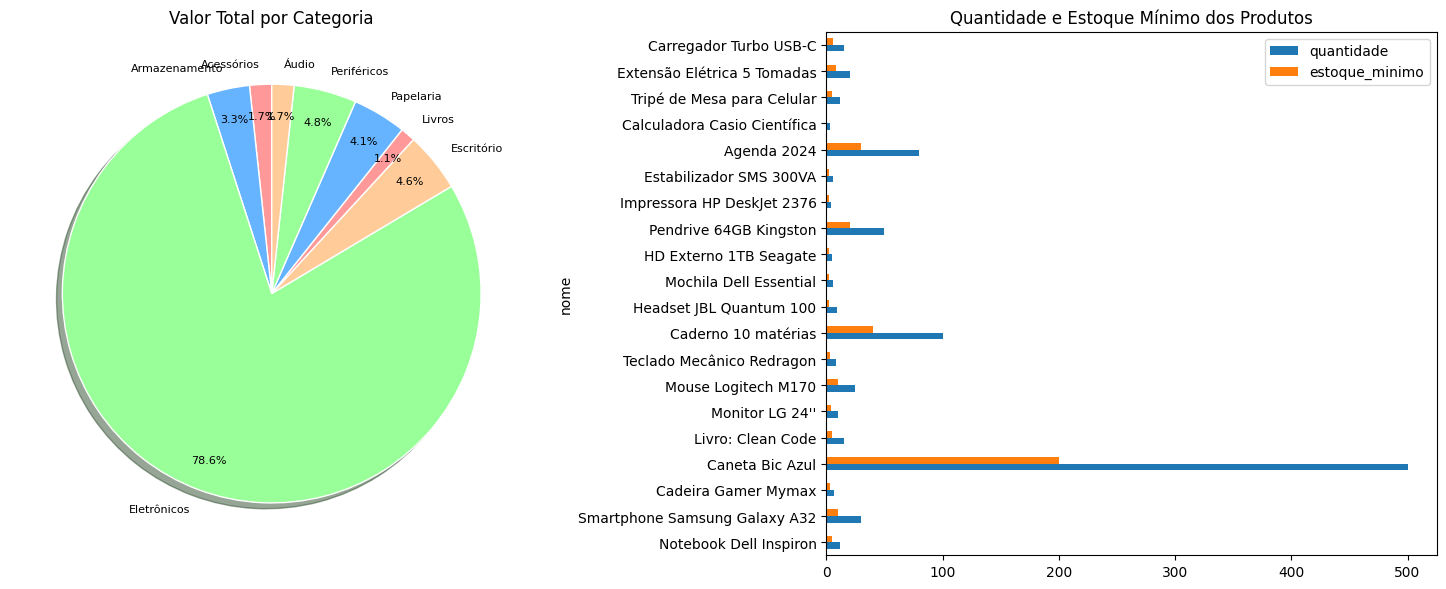

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# Lê o CSV com os produtos
df = pd.read_csv('vendas.csv')
print(df.head())

# Calcula o total de valor em estoque (preço * quantidade)
df['total'] = df['preco'] * df['quantidade']
total_geral = df['total'].sum()
print(f'Total de valor em estoque: R$ {total_geral:.2f}')

# Gráfico 1: Valor total por categoria
df['valor_total'] = df['preco'] * df['quantidade']
# Plotando o gráfico de valor total por categoria
fig, axes = plt.subplots(1, 2, figsize=(15, 6))  # 1 linha e 2 colunas de gráficos

df.groupby('categoria')['valor_total'].sum().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    ax=axes[0],
    title="Valor Total por Categoria",
    legend=False,
    ylabel='',  # Remove o rótulo do eixo y
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'],  # Cores personalizadas
    wedgeprops=dict(edgecolor='w'),  # Adiciona bordas brancas entre as fatias
    pctdistance=0.85,  # Distância entre o centro do gráfico e as fatias
    shadow=True,  # Adiciona sombra às fatias
    fontsize=8  # Tamanho da fonte dos rótulos
)

# Gráfico 2: Quantidade e estoque mínimo por produto
df.plot(
    kind='barh',
    x='nome',  # Substitua por sua coluna de produto
    y=['quantidade', 'estoque_minimo'],  # Substitua pelos nomes corretos das colunas
    ax=axes[1],
    title="Quantidade e Estoque Mínimo dos Produtos",
)

# Ajusta o layout para evitar sobreposição
plt.tight_layout()
plt.show()


